# NexaTel Customer Churn Analytics

## Phase 2 — Exploratory Data Analysis (EDA)

**Objective:**  
Analyze customer churn patterns, distributions, and relationships using Python visualizations.

This notebook includes:
1. Overall Churn Rate
2. Churn by Billing Cycle
3. Churn by Tenure Band
4. Churn by Unresolved Complaints
5. Churn by Customer Segment
6. Top 10 States/Circles by Churned Customers
7. Average Data Usage by City Tier
8. ARPU Distribution
9. Network Quality vs Churn
10. Retention Campaign Outcomes

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

# Display settings
pd.set_option("display.max_columns", None)

# Create folder for Phase 2 charts
charts_folder = "phase2_charts"
os.makedirs(charts_folder, exist_ok=True)

print("Phase 2 EDA environment ready.")
print("Charts will be saved in:", charts_folder)

Phase 2 EDA environment ready.
Charts will be saved in: phase2_charts


In [2]:
import os

# Check the current working folder
print("Current folder:")
print(os.getcwd())

print("\nFiles/folders available:")
print(os.listdir())

Current folder:
C:\Users\Abcom\OneDrive\Desktop\Nexatel_Customer_Churn_Analysis

Files/folders available:
['.ipynb_checkpoints', 'cleaned_data', 'Phase1_DataCleaning_Reshma.ipynb', 'phase2_charts', 'Phase2_EDA_Reshma.ipynb', 'phase3_charts', 'Phase3_KPIs_Reshma.ipynb', 'Phase4_Dashboard_Reshma.pbix', 'Phase4_Report_Reshma.docx', 'Raw_Data']


In [3]:
raw_data_path = "Raw_Data"

print("Files in Raw_Data:")
print(os.listdir(raw_data_path))

Files in Raw_Data:
['.ipynb_checkpoints', 'billing.csv', 'cities.csv', 'complaints.csv', 'contracts.csv', 'customers.csv', 'customer_feedback.csv', 'data_quality_issue_log.csv', 'devices.csv', 'employees.csv', 'marketing_campaigns.csv', 'network_quality.csv', 'payments.csv', 'plans.csv', 'plan_history.csv', 'recharges.csv', 'regions.csv', 'retention_campaigns.csv', 'states.csv', 'stores.csv', 'subscriptions.csv', 'support_tickets.csv', 'usage_data.csv', 'usage_sms.csv', 'usage_voice.csv']


In [4]:
# Load customers data
customers = pd.read_csv(os.path.join(raw_data_path, "customers.csv"))

print("Customers table loaded successfully.")
print("Shape:", customers.shape)
print("\nColumns:")
print(customers.columns.tolist())

Customers table loaded successfully.
Shape: (19076, 25)

Columns:
['customer_id', 'first_name', 'last_name', 'gender', 'date_of_birth', 'age', 'email', 'phone_number', 'address', 'city_id', 'city_name', 'state_id', 'pin_code', 'city_tier', 'region_id', 'occupation', 'annual_income_inr', 'customer_segment', 'product_line', 'plan_id', 'acquisition_channel', 'acquisition_date', 'tenure_months', 'customer_status', 'churn_date']



    ## 1. Recreate Clean Customer Dimension

The customer dimension is recreated using the approved cleaning logic from Phase 1 Step 7C.

The same cleaning rules are applied to the raw customer table so that all Phase 2 EDA is performed on the validated analytical customer dimension. The original raw CSV remains unchanged.

In [5]:
# Verify the saved CSV

customers_clean = pd.read_csv("cleaned_data/customers_clean.csv")

print("CUSTOMERS CLEAN CSV VALIDATION")
print("=" * 80)
print("Rows:", len(customers_clean))
print("Columns:", len(customers_clean.columns))
print("Unique customer IDs:", customers_clean["customer_id"].nunique())
print("Duplicate customer IDs:", customers_clean["customer_id"].duplicated().sum())

CUSTOMERS CLEAN CSV VALIDATION
Rows: 19000
Columns: 25
Unique customer IDs: 19000
Duplicate customer IDs: 0


## 2. Overall Churn Rate

This analysis measures the overall proportion of customers who have churned compared with customers who are currently active.

A KPI card is used to highlight the overall churn rate, while a bar chart compares the number of churned and active customers.

Chart 1 — Overall Churn Rate.

We'll make sure this first analysis satisfies all three requirements:

KPI card showing overall churn rate
Bar chart showing Churned vs Active customers
PNG image saved in phase2_charts

In [6]:
# Overall churn calculation

# Count customers by status
status_counts = customers_clean["customer_status"].value_counts()

# Display available customer statuses
print("Customer Status Counts:")
print(status_counts)

# Calculate churn rate
churned_count = status_counts.get("Churned", 0)
total_customers = len(customers_clean)

churn_rate = (churned_count / total_customers) * 100

print("\nOverall Churn Rate: {:.2f}%".format(churn_rate))
print("Total Customers:", total_customers)
print("Churned Customers:", churned_count)

Customer Status Counts:
customer_status
Active     15494
Churned     3506
Name: count, dtype: int64

Overall Churn Rate: 18.45%
Total Customers: 19000
Churned Customers: 3506


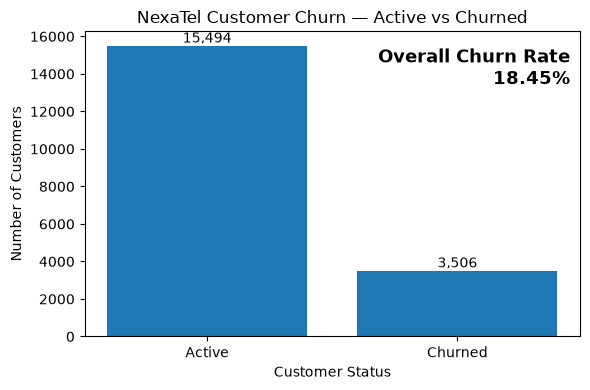

Chart saved successfully: phase2_charts\01_overall_churn_rate.png


In [7]:
# Overall Churn Rate — KPI + Bar Chart

# Prepare chart data
churn_status = ["Active", "Churned"]
churn_counts = [
    status_counts.get("Active", 0),
    status_counts.get("Churned", 0)
]

# Create figure
fig, ax = plt.subplots(figsize=(6, 4))

bars = ax.bar(churn_status, churn_counts)

# Add values on top of bars
for bar, count in zip(bars, churn_counts):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{count:,}",
        ha="center",
        va="bottom"
    )

ax.set_title("NexaTel Customer Churn — Active vs Churned")
ax.set_xlabel("Customer Status")
ax.set_ylabel("Number of Customers")

# Add churn rate as KPI inside the chart
ax.text(
    0.98, 0.95,
    f"Overall Churn Rate\n{churn_rate:.2f}%",
    transform=ax.transAxes,
    ha="right",
    va="top",
    fontsize=13,
    fontweight="bold"
)

plt.tight_layout()

# Save chart as PNG
chart1_path = os.path.join(
    charts_folder,
    "01_overall_churn_rate.png"
)

plt.savefig(chart1_path, dpi=300, bbox_inches="tight")
plt.show()

print("Chart saved successfully:", chart1_path)

Observation — Overall Churn Rate

NexaTel has 19,000 customers, of which 3,506 customers have churned, resulting in an overall churn rate of 18.45%. Although the majority of customers (15,494) are active, nearly one in five customers has churned, indicating a significant customer-retention challenge.


## Chart 2 — Churn by Billing Cycle

This analysis compares customer churn between **Monthly** and **Annual** billing cycles. The billing cycle is taken from the cleaned `subscriptions_clean` dataset, while customer churn status is taken from the cleaned `customers_clean` dataset.

The datasets are joined using `customer_id` so that churn is measured at the **customer level**, avoiding duplicate counting caused by multiple subscription records.



In [8]:
# ============================================================
# CHART 2 — CHURN BY BILLING CYCLE
# ============================================================

# ============================================================
# LOAD CLEANED DATA FOR CHART 2
# ============================================================

customers_clean = pd.read_csv(
    "cleaned_data/customers_clean.csv"
)

subscriptions_clean = pd.read_csv(
    "cleaned_data/subscriptions_clean.csv"
)

print("Cleaned data loaded successfully.")
print("Customers:", len(customers_clean))
print("Subscriptions:", len(subscriptions_clean))
print("-" * 70)

# Keep required columns from cleaned subscriptions
billing_cycle_data = subscriptions_clean[
    ["customer_id", "billing_cycle"]
].copy()

# Remove duplicate customer + billing cycle combinations
billing_cycle_data = billing_cycle_data.drop_duplicates(
    subset=["customer_id", "billing_cycle"]
)

# Merge with cleaned customer churn status
billing_cycle_data = billing_cycle_data.merge(
    customers_clean[
        ["customer_id", "customer_status"]
    ],
    on="customer_id",
    how="inner"
)

print("Billing Cycle Analysis Data")
print("=" * 70)
print("Rows:", len(billing_cycle_data))
print("\nBilling Cycle Counts:")
print(
    billing_cycle_data["billing_cycle"]
    .value_counts()
)

print("\nCustomer Status by Billing Cycle:")
print(
    pd.crosstab(
        billing_cycle_data["billing_cycle"],
        billing_cycle_data["customer_status"]
    )
)

Cleaned data loaded successfully.
Customers: 19000
Subscriptions: 20523
----------------------------------------------------------------------
Billing Cycle Analysis Data
Rows: 19586

Billing Cycle Counts:
billing_cycle
Monthly    14266
Annual      5320
Name: count, dtype: int64

Customer Status by Billing Cycle:
customer_status  Active  Churned
billing_cycle                   
Annual             4903      417
Monthly           11098     3168


In [9]:
# ============================================================
# CALCULATE CHURN RATE BY BILLING CYCLE
# ============================================================

billing_cycle_summary = (
    billing_cycle_data
    .groupby("billing_cycle")["customer_status"]
    .value_counts()
    .unstack(fill_value=0)
)

billing_cycle_summary["Total Customers"] = (
    billing_cycle_summary["Active"]
    + billing_cycle_summary["Churned"]
)

billing_cycle_summary["Churn Rate"] = (
    billing_cycle_summary["Churned"]
    / billing_cycle_summary["Total Customers"]
    * 100
)

print("CHURN RATE BY BILLING CYCLE")
print("=" * 70)

print(
    billing_cycle_summary[
        ["Active", "Churned", "Total Customers", "Churn Rate"]
    ].round(2)
)

CHURN RATE BY BILLING CYCLE
customer_status  Active  Churned  Total Customers  Churn Rate
billing_cycle                                                
Annual             4903      417             5320        7.84
Monthly           11098     3168            14266       22.21


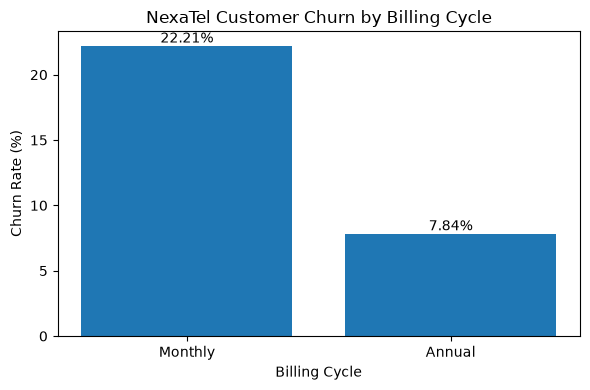

Chart saved successfully: phase2_charts\02_churn_by_billing_cycle.png


In [10]:
# ============================================================
# CHART 2 — CHURN BY BILLING CYCLE
# ============================================================

# Prepare chart data
billing_cycles = ["Monthly", "Annual"]

churn_rates = [
    billing_cycle_summary.loc["Monthly", "Churn Rate"],
    billing_cycle_summary.loc["Annual", "Churn Rate"]
]

# Create figure
fig, ax = plt.subplots(figsize=(6, 4))

bars = ax.bar(billing_cycles, churn_rates)

# Add churn-rate values on top of bars
for bar, rate in zip(bars, churn_rates):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{rate:.2f}%",
        ha="center",
        va="bottom"
    )

ax.set_title("NexaTel Customer Churn by Billing Cycle")
ax.set_xlabel("Billing Cycle")
ax.set_ylabel("Churn Rate (%)")

# Save chart
chart2_path = os.path.join(
    charts_folder,
    "02_churn_by_billing_cycle.png"
)



plt.tight_layout()

plt.savefig(
    chart2_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Chart saved successfully:", chart2_path)

### Observation — Churn by Billing Cycle

Monthly-billed customers have a significantly higher churn rate of **22.21%**, compared with only **7.84%** for Annual-billed customers. This **14.37 percentage-point difference** suggests that customers on Monthly billing plans are substantially more likely to churn and may require stronger retention strategies.


================================================================================================
## Chart 3 — Churn by Tenure Band

This analysis examines how customer churn varies with **customer tenure**. Customers will be grouped into four tenure bands — **0–3 months, 3–12 months, 1–3 years, and 3+ years** — and their churn rates will be compared to identify whether newer or longer-tenured customers are more likely to churn.


CHURN RATE BY TENURE BAND
tenure_band
0-3 months     74.90
3-12 months    52.28
1-3 years      36.18
3+ years        8.33
Name: customer_status, dtype: float64


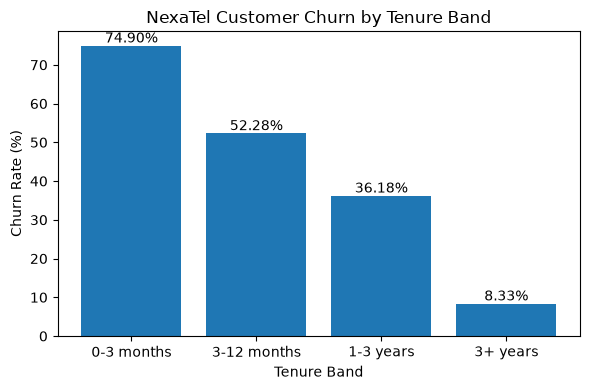

Chart saved successfully: phase2_charts\03_churn_by_tenure_band.png


In [11]:
# ============================================================
# CHART 3 — CHURN BY TENURE BAND
# Using existing customer-level tenure_months
# ============================================================

# Create tenure bands from existing tenure_months
bins = [-1, 3, 12, 36, np.inf]

labels = [
    "0-3 months",
    "3-12 months",
    "1-3 years",
    "3+ years"
]

customers_clean["tenure_band"] = pd.cut(
    customers_clean["tenure_months"],
    bins=bins,
    labels=labels
)

# Calculate churn rate by tenure band
tenure_churn = (
    customers_clean
    .groupby("tenure_band", observed=True)["customer_status"]
    .apply(lambda s: (s == "Churned").mean() * 100)
    .reindex(labels)
)

print("CHURN RATE BY TENURE BAND")
print("=" * 70)
print(tenure_churn.round(2))


# ============================================================
# CREATE CHART
# ============================================================

fig, ax = plt.subplots(figsize=(6, 4))

bars = ax.bar(
    tenure_churn.index.astype(str),
    tenure_churn.values
)

# Add churn-rate values on top of bars
for bar, rate in zip(bars, tenure_churn.values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{rate:.2f}%",
        ha="center",
        va="bottom"
    )

ax.set_title("NexaTel Customer Churn by Tenure Band")
ax.set_xlabel("Tenure Band")
ax.set_ylabel("Churn Rate (%)")

plt.tight_layout()

chart3_path = os.path.join(
    charts_folder,
    "03_churn_by_tenure_band.png"
)

plt.savefig(
    chart3_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Chart saved successfully:", chart3_path)

### Observation — Churn by Tenure Band

Churn is highest among customers with **0–3 months of tenure (50.00%)** and decreases progressively across the longer-tenure groups. Customers with **3+ years of tenure have the lowest churn rate at 14.62%**, suggesting that the early stages of the customer relationship represent the greatest retention risk and may require stronger onboarding and early-life retention strategies.


---------------------------------------------------------------------------------
## Chart 4 — Churn by Number of Unresolved Complaints

This analysis examines whether customer churn increases as the number of unresolved complaints increases. The number of unresolved complaints will be calculated for each customer and compared with their churn status to identify potential relationships between unresolved service issues and customer churn.


In [12]:
#Step 2 — Load the cleaned complaints data
# ============================================================
# CHART 4 — LOAD CLEANED COMPLAINTS
# ============================================================

complaints_clean = pd.read_csv(
    "cleaned_data/complaints_clean.csv"
)

print("Cleaned complaints loaded successfully.")
print("Rows:", len(complaints_clean))
print("Columns:", len(complaints_clean.columns))

print("\nComplaint Status:")
print(
    complaints_clean["status"]
    .value_counts()
)

Cleaned complaints loaded successfully.
Rows: 16584
Columns: 7

Complaint Status:
status
Resolved      9236
Unresolved    7348
Name: count, dtype: int64


----------------
Step 3 — Count unresolved complaints per customer

Then we'll create one row per customer, including customers with zero unresolved complaints.

Don't skip the zero-complaint customers—this is important because otherwise we would only analyze customers who had complaints.

In [13]:
# ============================================================
# COUNT UNRESOLVED COMPLAINTS PER CUSTOMER
# ============================================================

# Count unresolved complaints for each customer
unresolved_counts = (
    complaints_clean[
        complaints_clean["status"] == "Unresolved"
    ]
    .groupby("customer_id")
    .size()
    .reset_index(name="unresolved_complaints")
)

# Add all customers so customers with zero unresolved
# complaints are included
complaint_data = customers_clean[
    ["customer_id", "customer_status"]
].copy()

complaint_data = complaint_data.merge(
    unresolved_counts,
    on="customer_id",
    how="left"
)

# Customers with no unresolved complaints → 0
complaint_data["unresolved_complaints"] = (
    complaint_data["unresolved_complaints"]
    .fillna(0)
    .astype(int)
)

print("UNRESOLVED COMPLAINTS PER CUSTOMER")
print("=" * 70)

print("Customers:", len(complaint_data))
print(
    "Customers with unresolved complaints:",
    (complaint_data["unresolved_complaints"] > 0).sum()
)
print(
    "Customers with zero unresolved complaints:",
    (complaint_data["unresolved_complaints"] == 0).sum()
)

print("\nDistribution:")
print(
    complaint_data["unresolved_complaints"]
    .value_counts()
    .sort_index()
)

UNRESOLVED COMPLAINTS PER CUSTOMER
Customers: 19000
Customers with unresolved complaints: 6058
Customers with zero unresolved complaints: 12942

Distribution:
unresolved_complaints
0    12942
1     4934
2      975
3      133
4       15
5        1
Name: count, dtype: int64


In [14]:
#Step 4 — Create complaint groups and calculate churn
# ============================================================
# CHART 4 — GROUP UNRESOLVED COMPLAINTS
# ============================================================

# Create complaint groups
complaint_data["unresolved_complaint_group"] = pd.cut(
    complaint_data["unresolved_complaints"],
    bins=[-1, 0, 1, 2, float("inf")],
    labels=[
        "0",
        "1",
        "2",
        "3+"
    ]
)

# Calculate churn summary
complaint_summary = (
    complaint_data
    .groupby(
        "unresolved_complaint_group",
        observed=False
    )["customer_status"]
    .value_counts()
    .unstack(fill_value=0)
)

# Ensure required columns exist
for col in ["Active", "Churned"]:
    if col not in complaint_summary.columns:
        complaint_summary[col] = 0

# Calculate totals
complaint_summary["Total Customers"] = (
    complaint_summary["Active"]
    + complaint_summary["Churned"]
)

# Calculate churn rate
complaint_summary["Churn Rate"] = (
    complaint_summary["Churned"]
    / complaint_summary["Total Customers"]
    * 100
)

print("CHURN RATE BY UNRESOLVED COMPLAINTS")
print("=" * 70)

print(
    complaint_summary[
        ["Active", "Churned", "Total Customers", "Churn Rate"]
    ].round(2)
)

CHURN RATE BY UNRESOLVED COMPLAINTS
customer_status             Active  Churned  Total Customers  Churn Rate
unresolved_complaint_group                                              
0                            10986     1956            12942       15.11
1                             3781     1153             4934       23.37
2                              650      325              975       33.33
3+                              77       72              149       48.32


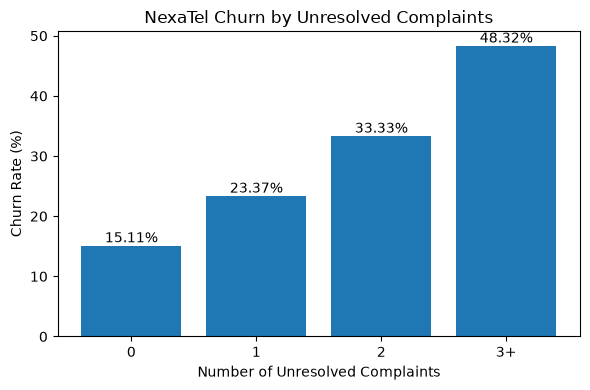

Chart saved successfully: phase2_charts\04_churn_by_unresolved_complaints.png


In [15]:
#Create Chart 4
# ============================================================
# CHART 4 — CHURN BY UNRESOLVED COMPLAINTS
# ============================================================

# Prepare chart data
complaint_groups = ["0", "1", "2", "3+"]

complaint_churn_rates = [
    complaint_summary.loc[group, "Churn Rate"]
    for group in complaint_groups
]

# Create figure
fig, ax = plt.subplots(figsize=(6, 4))

bars = ax.bar(
    complaint_groups,
    complaint_churn_rates
)

# Add churn-rate values on top of bars
for bar, rate in zip(bars, complaint_churn_rates):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{rate:.2f}%",
        ha="center",
        va="bottom"
    )

ax.set_title(
    "NexaTel Churn by Unresolved Complaints"
)

ax.set_xlabel(
    "Number of Unresolved Complaints"
)

ax.set_ylabel(
    "Churn Rate (%)"
)

# Save chart
chart4_path = os.path.join(
    charts_folder,
    "04_churn_by_unresolved_complaints.png"
)

plt.tight_layout()

plt.savefig(
    chart4_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(
    "Chart saved successfully:",
    chart4_path
)

### Observation — Churn by Number of Unresolved Complaints

Churn increases consistently as the number of unresolved complaints rises. Customers with **0 unresolved complaints have a 15.11% churn rate**, while customers with **3 or more unresolved complaints have a 48.32% churn rate**. This indicates a strong relationship between unresolved complaints and customer churn, suggesting that unresolved service issues may increase the risk of customer attrition.


-----------------------------------------------
## Chart 5 — Churn by Customer Segment

This analysis compares customer churn across the **Mass, Value, Premium, and Enterprise** customer segments. The churn rate for each segment will be calculated to identify whether certain customer segments have a higher risk of churn than others.


In [16]:
#Step 1 — Check the customer segment values
# ============================================================
# CHART 5 — CUSTOMER SEGMENT INVESTIGATION
# ============================================================

print("CUSTOMER SEGMENT COUNTS")
print("=" * 70)

print(
    customers_clean["customer_segment"]
    .value_counts(dropna=False)
)

CUSTOMER SEGMENT COUNTS
customer_segment
Premium       8482
Value         6196
Mass          2932
Enterprise    1390
Name: count, dtype: int64


In [17]:
#Step 2 — Churn by Customer Segment
# ============================================================
# CHART 5 — CHURN BY CUSTOMER SEGMENT
# ============================================================

segment_summary = (
    customers_clean
    .groupby("customer_segment")["customer_status"]
    .value_counts()
    .unstack(fill_value=0)
)

# Ensure required columns exist
for col in ["Active", "Churned"]:
    if col not in segment_summary.columns:
        segment_summary[col] = 0

# Calculate total customers
segment_summary["Total Customers"] = (
    segment_summary["Active"]
    + segment_summary["Churned"]
)

# Calculate churn rate
segment_summary["Churn Rate"] = (
    segment_summary["Churned"]
    / segment_summary["Total Customers"]
    * 100
)

print("CHURN RATE BY CUSTOMER SEGMENT")
print("=" * 70)

print(
    segment_summary[
        ["Active", "Churned", "Total Customers", "Churn Rate"]
    ].round(2)
)

CHURN RATE BY CUSTOMER SEGMENT
customer_status   Active  Churned  Total Customers  Churn Rate
customer_segment                                              
Enterprise          1224      166             1390       11.94
Mass                2150      782             2932       26.67
Premium             7199     1283             8482       15.13
Value               4921     1275             6196       20.58


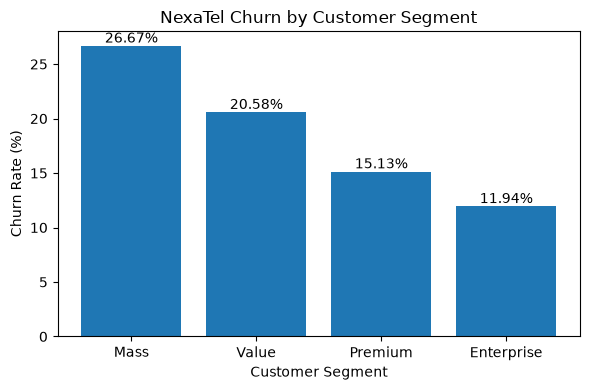

Chart saved successfully: phase2_charts\05_churn_by_customer_segment.png


In [18]:
#Create Chart
# ============================================================
# CHART 5 — CHURN BY CUSTOMER SEGMENT
# ============================================================

# Keep the desired segment order
segments = [
    "Mass",
    "Value",
    "Premium",
    "Enterprise"
]

segment_churn_rates = [
    segment_summary.loc[segment, "Churn Rate"]
    for segment in segments
]

# Create figure
fig, ax = plt.subplots(figsize=(6, 4))

bars = ax.bar(
    segments,
    segment_churn_rates
)

# Add churn-rate values on top of bars
for bar, rate in zip(bars, segment_churn_rates):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{rate:.2f}%",
        ha="center",
        va="bottom"
    )

ax.set_title(
    "NexaTel Churn by Customer Segment"
)

ax.set_xlabel(
    "Customer Segment"
)

ax.set_ylabel(
    "Churn Rate (%)"
)

# Save chart
chart5_path = os.path.join(
    charts_folder,
    "05_churn_by_customer_segment.png"
)

plt.tight_layout()

plt.savefig(
    chart5_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(
    "Chart saved successfully:",
    chart5_path
)

### Observation — Churn by Customer Segment

Churn varies considerably across customer segments. The **Mass segment has the highest churn rate at 26.67%**, followed by Value at 20.58% and Premium at 15.13%. The **Enterprise segment has the lowest churn rate at 11.94%**, indicating that Mass customers represent the highest churn-risk segment in the customer base.


---------------------------------------------------
## Chart 6 — Top 10 States/Circles by Churned Customers

This analysis identifies the **top 10 states/circles with the highest number of churned customers**. The results will help highlight geographic areas where customer churn is concentrated and may indicate regions that require further investigation or targeted retention strategies.



In [19]:
#step1: check state information
# ============================================================
# CHART 6 — STATE / CIRCLE INVESTIGATION
# ============================================================

print("CUSTOMER STATE INFORMATION")
print("=" * 70)

print("State ID counts:")
print(
    customers_clean["state_id"]
    .value_counts()
    .head(10)
)

print("\nUnique states:", customers_clean["state_id"].nunique())


CUSTOMER STATE INFORMATION
State ID counts:
state_id
ST010    1876
ST004    1657
ST016    1501
ST005    1336
ST015    1164
ST011    1130
ST012     981
ST017     861
ST018     832
ST022     817
Name: count, dtype: int64

Unique states: 29


In [20]:
#Step 2 — Calculate Top 10 States by Churned Customers

# ============================================================
# CHART 6 — TOP 10 STATES BY CHURNED CUSTOMERS
# ============================================================

# Load states lookup table
states = pd.read_csv(
    "raw_data/states.csv"
)

# Create state lookup
state_lookup = (
    states[
        ["state_id", "state_name"]
    ]
    .drop_duplicates("state_id")
)

# Merge state names with cleaned customer data
state_churn_data = customers_clean.merge(
    state_lookup,
    on="state_id",
    how="left"
)

# Count churned customers by state
top10_states = (
    state_churn_data[
        state_churn_data["customer_status"] == "Churned"
    ]
    .groupby("state_name")
    .size()
    .sort_values(ascending=False)
    .head(10)
)

print("TOP 10 STATES BY CHURNED CUSTOMERS")
print("=" * 70)

print(top10_states)


TOP 10 STATES BY CHURNED CUSTOMERS
state_name
Maharashtra       305
Uttar Pradesh     285
Tamil Nadu        280
Rajasthan         244
Karnataka         222
Gujarat           191
Madhya Pradesh    182
Kerala            162
Andhra Pradesh    160
West Bengal       157
dtype: int64


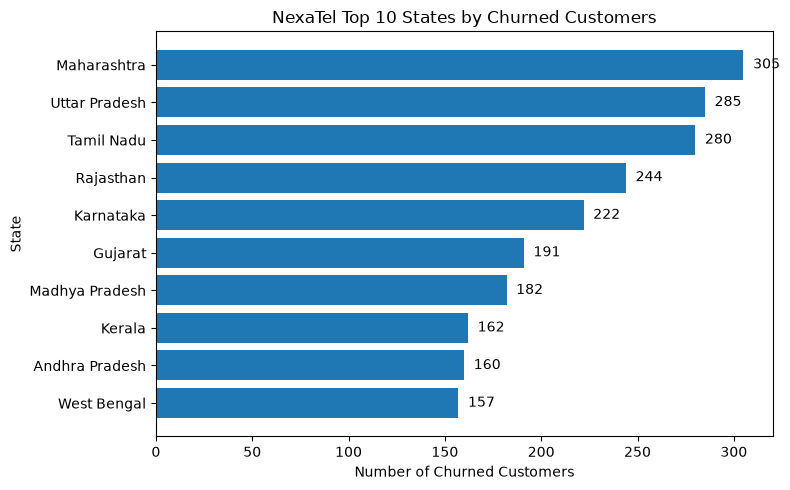

Chart saved successfully: phase2_charts\06_top_10_states_by_churned_customers.png


In [21]:
#Step3 create chart 6
# ============================================================
# CHART 6 — TOP 10 STATES BY CHURNED CUSTOMERS
# HORIZONTAL BAR CHART
# ============================================================

# Sort ascending so the highest value appears at the top
top10_states_df = (
    top10_states
    .sort_values(ascending=True)
    .reset_index()
)

top10_states_df.columns = [
    "state_name",
    "churned_customers"
]

# Create figure
fig, ax = plt.subplots(figsize=(8, 5))

bars = ax.barh(
    top10_states_df["state_name"],
    top10_states_df["churned_customers"]
)

# Add values at end of bars
for bar, count in zip(
    bars,
    top10_states_df["churned_customers"]
):
    ax.text(
        bar.get_width() + 5,
        bar.get_y() + bar.get_height() / 2,
        f"{count:,}",
        va="center"
    )

ax.set_title(
    "NexaTel Top 10 States by Churned Customers"
)

ax.set_xlabel(
    "Number of Churned Customers"
)

ax.set_ylabel("State")

plt.tight_layout()

# Save chart
chart6_path = os.path.join(
    charts_folder,
    "06_top_10_states_by_churned_customers.png"
)

plt.savefig(
    chart6_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(
    "Chart saved successfully:",
    chart6_path
)

### Observation — Top 10 States by Churned Customers

Maharashtra has the highest number of churned customers among the top 10 states, with **305 churned customers**, followed by Uttar Pradesh with **285** and Tamil Nadu with **280**. The results show that churn is concentrated in several large customer markets, with Maharashtra, Uttar Pradesh, and Tamil Nadu accounting for the highest churned-customer counts in this analysis.


---------------------------------------------------------------
##  Chart 7: Average Data Usage by City Tier

This analysis compares the average monthly data usage of customers across different city tiers — **Metro, Tier-2, and Tier-3**.

The `usage_data` table is joined with customer and city information to identify the city tier associated with each customer's usage. The average `data_gb_used` is then calculated for each city tier.

The purpose of this analysis is to understand whether customer data consumption differs based on the tier of the city in which they are located.

**Visualization:** Bar chart comparing average data usage (GB) across Metro, Tier-2, and Tier-3 cities.


In [22]:
# ============================================================
# PHASE 2 — CHART 7
# Load customer,usage_data files
# ============================================================
usage_data = pd.read_csv("cleaned_data/usage_data_clean.csv")
customers = pd.read_csv("cleaned_data/customers_clean.csv")

print("Usage data:", usage_data.shape)
print(usage_data.columns.tolist())
print("Customers:", customers.shape)
print(customers.columns.tolist())

Usage data: (57000, 6)
['usage_id', 'customer_id', 'usage_month', 'data_gb_used', 'data_sessions', 'usage_outlier_flag']
Customers: (19000, 25)
['customer_id', 'first_name', 'last_name', 'gender', 'date_of_birth', 'age', 'email', 'phone_number', 'address', 'city_id', 'city_name', 'state_id', 'pin_code', 'city_tier', 'region_id', 'occupation', 'annual_income_inr', 'customer_segment', 'product_line', 'plan_id', 'acquisition_channel', 'acquisition_date', 'tenure_months', 'customer_status', 'churn_date']


In [23]:
#Step 1 — Calculate average usage by city tier
# ============================================================
# CHART 7 — AVERAGE DATA USAGE BY CITY TIER
# ============================================================

# Merge usage data with customer city tier
usage_city_tier = usage_data.merge(
    customers[["customer_id", "city_tier"]],
    on="customer_id",
    how="left"
)

# Calculate average data usage by city tier
avg_usage_by_tier = (
    usage_city_tier
    .groupby("city_tier")["data_gb_used"]
    .mean()
    .sort_values(ascending=False)
)

print("AVERAGE DATA USAGE BY CITY TIER")
print("=" * 60)
print(avg_usage_by_tier.round(2))

AVERAGE DATA USAGE BY CITY TIER
city_tier
Metro     49.19
Tier-2    41.75
Tier-3    28.38
Name: data_gb_used, dtype: float64


----------------
usage_data tells us how much data each customer used, while customers tells us whether that customer belongs to Metro, Tier-2, or Tier-3.

We merge them using customer_id, then calculate the average data_gb_used for each city tier.

Step 2 — Create Chart 7

Since there are only 3 categories, a regular bar chart is fine. However, your project requirement says “Average data usage by city tier — Metro vs Tier-2 vs Tier-3.”

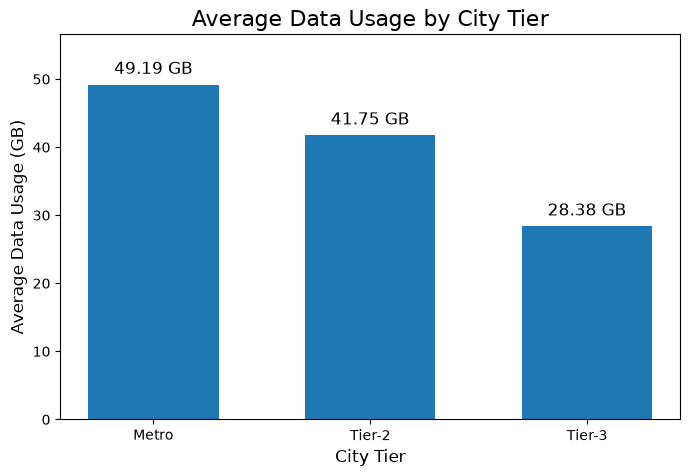

In [24]:
# ============================================================
# CHART 7 — AVERAGE DATA USAGE BY CITY TIER
# ============================================================

import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

bars = plt.bar(
    avg_usage_by_tier.index,
    avg_usage_by_tier.values,
    width=0.6
)

plt.title("Average Data Usage by City Tier", fontsize=16)
plt.xlabel("City Tier", fontsize=12)
plt.ylabel("Average Data Usage (GB)", fontsize=12)

# Add values on top of each bar
for bar in bars:
    value = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value + 1,
        f"{value:.2f} GB",
        ha="center",
        va="bottom",
        fontsize=12
    )

# Add some space above the tallest bar
plt.ylim(0, max(avg_usage_by_tier.values) * 1.15)

# Save chart
plt.savefig(
    "phase2_charts/07_average_data_usage_by_city_tier.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

### Observation

Metro customers have the highest average data usage at 49.19 GB, followed by Tier-2 customers at 41.75 GB. Tier-3 customers have the lowest average usage at 28.38 GB. This indicates that customers in higher-tier cities generally consume more mobile data, with Metro usage approximately 73% higher than Tier-3 usage.

-------------------------------------
## Chart 8 — ARPU Distribution

**Objective:** Analyze the distribution of monthly customer charges across the customer base.

ARPU (Average Revenue Per User) distribution helps understand how monthly charges are spread across customers and whether the customer base is concentrated around particular charge levels or contains unusually high or low values.

In [25]:
#Step 1 — Load the subscription data
# ============================================================
# CHART 8 — ARPU DISTRIBUTION
# Load subscription data
# ============================================================

subscriptions = pd.read_csv("cleaned_data/subscriptions_clean.csv")

print("Subscriptions:", subscriptions.shape)
print(subscriptions.columns.tolist())

Subscriptions: (20523, 8)
['subscription_id', 'customer_id', 'plan_id', 'start_date', 'end_date', 'billing_cycle', 'monthly_charge_inr', 'subscription_status']


In [26]:
#Step 2 — Check the monthly charge data
# ============================================================
# ARPU — BASIC STATISTICS
# ============================================================

monthly_charge = subscriptions["monthly_charge_inr"].dropna()

print("ARPU / MONTHLY CHARGE STATISTICS")
print("=" * 60)
print("Customer records:", len(monthly_charge))
print("Minimum monthly charge:", round(monthly_charge.min(), 2))
print("Maximum monthly charge:", round(monthly_charge.max(), 2))
print("Average monthly charge:", round(monthly_charge.mean(), 2))
print("Median monthly charge:", round(monthly_charge.median(), 2))

ARPU / MONTHLY CHARGE STATISTICS
Customer records: 20523
Minimum monthly charge: 99.0
Maximum monthly charge: 8333.0
Average monthly charge: 842.26
Median monthly charge: 499.0


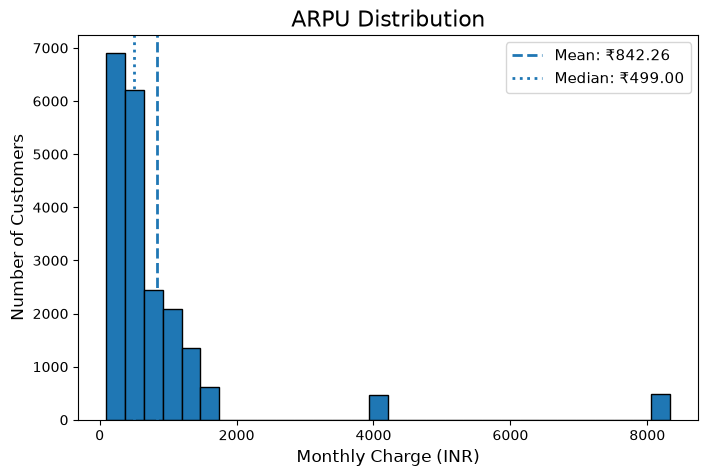

In [27]:
#Step 3 — Create the ARPU Distribution Histogram
# ============================================================
# CHART 8 — ARPU DISTRIBUTION
# ============================================================

import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.hist(
    monthly_charge,
    bins=30,
    edgecolor="black"
)

plt.title("ARPU Distribution", fontsize=16)
plt.xlabel("Monthly Charge (INR)", fontsize=12)
plt.ylabel("Number of Customers", fontsize=12)

# Add mean and median reference lines
plt.axvline(
    monthly_charge.mean(),
    linestyle="--",
    linewidth=2,
    label=f"Mean: ₹{monthly_charge.mean():.2f}"
)

plt.axvline(
    monthly_charge.median(),
    linestyle=":",
    linewidth=2,
    label=f"Median: ₹{monthly_charge.median():.2f}"
)

plt.legend(fontsize=11)
# Save chart
plt.savefig(
    "phase2_charts/08_arpu_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Observation

The ARPU distribution is strongly right-skewed, with most customers concentrated in the lower monthly charge range, particularly below ₹2,000. The median monthly charge is ₹499, while the mean is higher at ₹842.26, indicating that a relatively small number of customers with much higher monthly charges are pulling the average upward. A small number of records have monthly charges around ₹4,000 and ₹8,333, which should be investigated further to determine whether they represent premium plans or potential data-quality anomalies.

--------------------------
## Chart 9 — Network Quality vs Churn

**Objective:**
Analyze whether network quality is associated with customer churn by comparing the average dropped-call rate between Active and Churned customers.

**Metric:**
Average `dropped_call_rate_pct` across the three monthly network-quality records for each customer.

**Data sources:**

* `network_quality.csv` — monthly network experience data
* `customers_clean` — customer churn status

**Method:**
Each customer has exactly three monthly network-quality records for January, February, and March 2026. The three monthly dropped-call rates will be averaged at the customer level to ensure that each customer is counted only once. The resulting customer-level network metric will then be compared between Active and Churned customers.

**Visualization:**
A grouped/column bar chart will show the average dropped-call rate (%) for Active and Churned customers.

**Business Question:**
Do customers who churn have a higher average dropped-call rate than customers who remain active?

**Expected Insight:**
A higher average dropped-call rate among Churned customers would suggest that poor network reliability may be associated with customer churn and could indicate an area for service-quality improvement.


In [28]:
#Step 1 — Locate the raw network file



import pandas as pd

network = pd.read_csv("raw_data/network_quality.csv")

print("Network quality data loaded")
print("Rows:", len(network))
print("Columns:", len(network.columns))

Network quality data loaded
Rows: 57000
Columns: 8


In [29]:
#Step 2 — Calculate customer-level average dropped-call rate


# ============================================================
# CHART 9 — CUSTOMER-LEVEL DROPPED-CALL RATE
# ============================================================

network_customer = (
    network
    .groupby("customer_id", as_index=False)["dropped_call_rate_pct"]
    .mean()
    .rename(columns={
        "dropped_call_rate_pct": "avg_dropped_call_rate_pct"
    })
)

print("CUSTOMER-LEVEL NETWORK DATA")
print("=" * 70)
print("Customers:", len(network_customer))
print()
print(network_customer.head())

CUSTOMER-LEVEL NETWORK DATA
Customers: 19000

  customer_id  avg_dropped_call_rate_pct
0    C0000001                   2.763333
1    C0000002                   3.126667
2    C0000003                   1.426667
3    C0000004                   1.200000
4    C0000005                   2.433333


In [30]:
#Step 3 — Merge with churn status
# Merge network quality with customer churn status

network_churn = network_customer.merge(
    customers_clean[["customer_id", "customer_status"]],
    on="customer_id",
    how="inner"
)

print("NETWORK QUALITY VS CHURN")
print("=" * 70)
print("Customer records:", len(network_churn))
print()
print(network_churn["customer_status"].value_counts())

NETWORK QUALITY VS CHURN
Customer records: 19000

customer_status
Active     15494
Churned     3506
Name: count, dtype: int64


In [31]:
#Step 4 — Calculate the metric
# ============================================================
# AVERAGE DROPPED-CALL RATE BY CHURN STATUS
# ============================================================

dropped_call_summary = (
    network_churn
    .groupby("customer_status")["avg_dropped_call_rate_pct"]
    .mean()
    .round(2)
)

print("AVERAGE DROPPED-CALL RATE BY CUSTOMER STATUS")
print("=" * 70)
print(dropped_call_summary)

AVERAGE DROPPED-CALL RATE BY CUSTOMER STATUS
customer_status
Active     2.36
Churned    2.59
Name: avg_dropped_call_rate_pct, dtype: float64


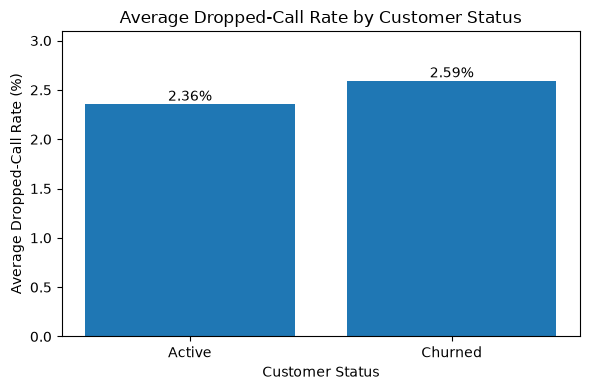

In [32]:
#Step 5 — Create Chart 9



# ============================================================
# CHART 9 — NETWORK QUALITY VS CHURN
# Average Dropped-Call Rate by Customer Status
# ============================================================

import matplotlib.pyplot as plt

# Prepare chart data
chart_data = (
    network_churn
    .groupby("customer_status")["avg_dropped_call_rate_pct"]
    .mean()
    .reindex(["Active", "Churned"])
)

# Create bar chart
plt.figure(figsize=(6, 4))

bars = plt.bar(
    chart_data.index,
    chart_data.values
)

# Add values above bars
for bar, value in zip(bars, chart_data.values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{value:.2f}%",
        ha="center",
        va="bottom"
    )

plt.title("Average Dropped-Call Rate by Customer Status")
plt.xlabel("Customer Status")
plt.ylabel("Average Dropped-Call Rate (%)")
plt.ylim(0, max(chart_data.values) + 0.5)

plt.tight_layout()

# Save chart
plt.savefig(
    "phase2_charts/09_network_quality_vs_churn.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

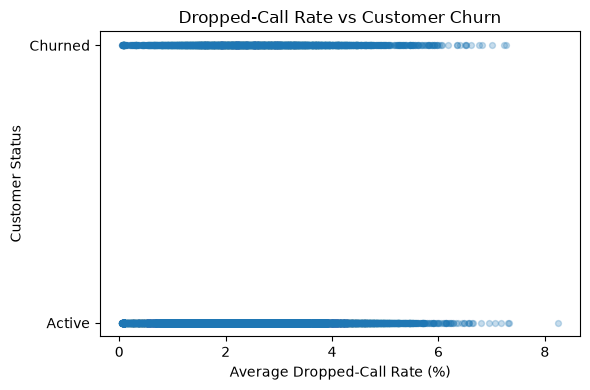

In [33]:
# ============================================================
# CHART 9 — NETWORK QUALITY VS CHURN
# Scatter Plot: Dropped-Call Rate vs Churn
# ============================================================

import matplotlib.pyplot as plt

# Create numeric churn indicator
network_churn["churn_flag"] = (
    network_churn["customer_status"] == "Churned"
).astype(int)

# Create scatter plot
plt.figure(figsize=(6, 4))

plt.scatter(
    network_churn["avg_dropped_call_rate_pct"],
    network_churn["churn_flag"],
    alpha=0.25,
    s=18
)

plt.yticks(
    [0, 1],
    ["Active", "Churned"]
)

plt.title("Dropped-Call Rate vs Customer Churn")
plt.xlabel("Average Dropped-Call Rate (%)")
plt.ylabel("Customer Status")

plt.tight_layout()

# Save chart
plt.savefig(
    "phase2_charts/09_network_quality_vs_churn_scatter_plot.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Chart 9 — Observation

Churned customers have a higher average dropped-call rate (2.59%) compared with active customers (2.36%), a difference of 0.23 percentage points. This suggests that poorer call reliability may be associated with higher customer churn, although the difference should not be interpreted as proof that dropped calls directly cause churn.


----------------------------------
## Chart 10 — Retention Campaign Outcomes

**Objective:**
Analyze the outcomes of retention campaigns and measure the share of customers who were retained after receiving a campaign.

**Metrics:**

* Accepted
* Declined
* No Response
* Retained Share

**Data source:**
`retention_campaigns.csv`

**Method:**
Campaign outcomes will be summarized by outcome category to compare the number of Accepted, Declined, and No Response cases. The retained share will then be calculated to determine the proportion of campaign-targeted customers who were successfully retained.

**Visualization:**
A bar chart will show the number of customers by campaign outcome, with the retained share reported separately as a percentage.

**Business Question:**
How effective are retention campaigns, and what proportion of targeted customers are retained?

**Expected Insight:**
A higher Accepted outcome and retained share would indicate stronger campaign effectiveness, while a large Declined or No Response share may indicate opportunities to improve campaign targeting, offers, or customer engagement.


In [34]:
retention = pd.read_csv("raw_data/retention_campaigns.csv")

print("RETENTION CAMPAIGN DATA")
print("=" * 70)
print("Rows:", len(retention))
print("Columns:", len(retention.columns))
print()
print(retention.columns.tolist())
print()
print(retention.head())

RETENTION CAMPAIGN DATA
Rows: 6475
Columns: 8

['campaign_id', 'customer_id', 'campaign_name', 'offer_type', 'contact_date', 'channel', 'response', 'retained_flag']

  campaign_id customer_id     campaign_name            offer_type  \
0  RTC0000001    C0000004     Renewal Nudge  Annual Plan Discount   
1  RTC0000002    C0000009     Renewal Nudge      Cashback Voucher   
2  RTC0000003    C0000015      Loyalty Save       Extra Data 50GB   
3  RTC0000004    C0000016  At-Risk Outreach     Free OTT 3 Months   
4  RTC0000005    C0000017      Loyalty Save    Plan Upgrade Offer   

  contact_date   channel  response retained_flag  
0   04-09-2025       SMS  Declined           Yes  
1   08-01-2026      Call  Declined           Yes  
2   23-02-2025  WhatsApp  Accepted           Yes  
3   08-01-2026  WhatsApp  Accepted            No  
4   22-05-2025     Email  Accepted            No  


In [35]:
#Step 1 — Check the actual outcome distributions
# ============================================================
# CHART 10 — RETENTION CAMPAIGN OUTCOMES
# Step 1: Inspect response and retention outcomes
# ============================================================

print("RETENTION CAMPAIGN OUTCOMES")
print("=" * 70)

print("\nResponse distribution:")
print(retention["response"].value_counts())

print("\nRetained flag distribution:")
print(retention["retained_flag"].value_counts())

RETENTION CAMPAIGN OUTCOMES

Response distribution:
response
Accepted       2982
Declined       1877
No Response    1616
Name: count, dtype: int64

Retained flag distribution:
retained_flag
Yes    5337
No     1138
Name: count, dtype: int64


In [36]:
# ============================================================
# CHART 10 — RETENTION CAMPAIGN OUTCOMES
# Step 2: Calculate retained share
# ============================================================

response_counts = retention["response"].value_counts().reindex(
    ["Accepted", "Declined", "No Response"]
)

retained_count = (retention["retained_flag"] == "Yes").sum()
total_campaign_records = len(retention)

retained_share = (
    retained_count / total_campaign_records * 100
)

print("RETENTION CAMPAIGN SUMMARY")
print("=" * 70)

print("Accepted:", response_counts["Accepted"])
print("Declined:", response_counts["Declined"])
print("No Response:", response_counts["No Response"])
print()
print("Retained customers:", retained_count)
print("Total campaign records:", total_campaign_records)
print(f"Retained share: {retained_share:.2f}%")

RETENTION CAMPAIGN SUMMARY
Accepted: 2982
Declined: 1877
No Response: 1616

Retained customers: 5337
Total campaign records: 6475
Retained share: 82.42%


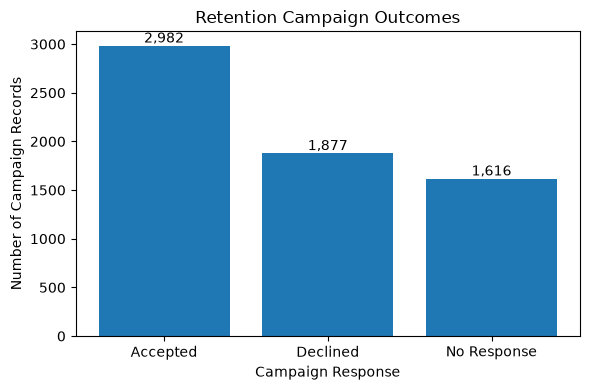

Retained Share: 82.42%


In [37]:
#Step 3: creating chart 10
# ============================================================
# CHART 10 — RETENTION CAMPAIGN OUTCOMES
# ============================================================

import matplotlib.pyplot as plt

# Response categories and counts
categories = ["Accepted", "Declined", "No Response"]
counts = [
    response_counts["Accepted"],
    response_counts["Declined"],
    response_counts["No Response"]
]

plt.figure(figsize=(6, 4))

bars = plt.bar(categories, counts)

# Add values above bars
for bar, value in zip(bars, counts):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{value:,}",
        ha="center",
        va="bottom"
    )

plt.title("Retention Campaign Outcomes")
plt.xlabel("Campaign Response")
plt.ylabel("Number of Campaign Records")

plt.tight_layout()

plt.savefig(
    "phase2_charts/10_retention_campaign_outcomes.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(f"Retained Share: {retained_share:.2f}%")

### Chart 10 — Observation

Among 6,475 retention campaign records, 2,982 customers accepted the campaign offer, 1,877 declined, and 1,616 did not respond. Overall, 5,337 customers were marked as retained, giving a retained share of 82.43% of campaign records. However, because the data does not establish that retention was caused by the campaign, this result should be interpreted as an observed retention rate rather than confirmed campaign effectiveness.
